In [4]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tableone import TableOne

In [5]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [6]:
DATA_DIR = Path('1.0.3/training_data')
extensions = ['hea', 'wav', 'tsv', 'txt']

files = {ext: list(DATA_DIR.rglob(f'*.{ext}')) for ext in extensions}

In [7]:
cohort = []
for txt in files['txt']:
    with open(txt, 'r') as f:
        lines = f.read().strip().split('\n')

    header = lines[0].split()
    patient_id, num_locations, sample_rate = header[0], int(header[1]), int(header[2])
    recordings = []
    for i in range(1, num_locations + 1):
        parts = lines[i].split()
        recordings.append({
            'location': parts[0],
            'hea_file': parts[1],
            'wav_file': parts[2],
            'tsv_file': parts[3]
        })

    metadata = {}
    for line in lines[num_locations + 1:]:
        if line.startswith('#'):
            key, value = line[1:].split(':', 1)
            value = value.strip()
            metadata[key.strip()] = np.nan if value == 'nan' else value

    cohort.append({
        'patient_id': patient_id,
        'num_locations': num_locations,
        'sample_rate': sample_rate,
        'recordings': recordings,
        'file_path': txt,
        **metadata
    })

cohort = pd.DataFrame(cohort)
cohort.to_csv('cohort.csv', index=False)
_ = pd.concat([pd.DataFrame(x) for x in cohort['recordings']], keys=cohort.index).reset_index(level=1, drop=True)
cohort = cohort.drop('recordings', axis=1).join(_).reset_index(drop=True)
cohort.head()

,patient_id,num_locations,sample_rate,file_path,Age,Sex,Height,Weight,Pregnancy status,Murmur,Murmur locations,Most audible location,Systolic murmur timing,Systolic murmur shape,Systolic murmur grading,Systolic murmur pitch,Systolic murmur quality,Diastolic murmur timing,Diastolic murmur shape,Diastolic murmur grading,Diastolic murmur pitch,Diastolic murmur quality,Outcome,Campaign,Additional ID,location,hea_file,wav_file,tsv_file
0,85210,4,4000,1.0.3/training_data/85210.txt,Child,Female,112.0,18.6,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2015,NaN,AV,85210_AV.hea,85210_AV.wav,85210_AV.tsv
1,85210,4,4000,1.0.3/training_data/85210.txt,Child,Female,112.0,18.6,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2015,NaN,PV,85210_PV.hea,85210_PV.wav,85210_PV.tsv
2,85210,4,4000,1.0.3/training_data/85210.txt,Child,Female,112.0,18.6,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2015,NaN,TV,85210_TV.hea,85210_TV.wav,85210_TV.tsv
3,85210,4,4000,1.0.3/training_data/85210.txt,Child,Female,112.0,18.6,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2015,NaN,MV,85210_MV.hea,85210_MV.wav,85210_MV.tsv
4,50388,4,4000,1.0.3/training_data/50388.txt,Child,Female,128.0,34.3,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2014,NaN,AV,50388_AV.hea,50388_AV.wav,50388_AV.tsv


In [8]:
cohort.dtypes

patient_id                  object
num_locations                int64
sample_rate                  int64
file_path                   object
Age                         object
Sex                         object
Height                      object
Weight                      object
Pregnancy status            object
Murmur                      object
Murmur locations            object
Most audible location       object
Systolic murmur timing      object
Systolic murmur shape       object
Systolic murmur grading     object
Systolic murmur pitch       object
Systolic murmur quality     object
Diastolic murmur timing     object
Diastolic murmur shape      object
Diastolic murmur grading    object
Diastolic murmur pitch      object
Diastolic murmur quality    object
Outcome                     object
Campaign                    object
Additional ID               object
location                    object
hea_file                    object
wav_file                    object
tsv_file            

In [9]:
dtype_map = {
    'category': ['Age', 'Sex', 'Pregnancy status', 'Murmur', 'Systolic murmur timing',
                 'Systolic murmur shape', 'Systolic murmur grading', 'Systolic murmur pitch',
                 'Systolic murmur quality', 'Diastolic murmur timing', 'Diastolic murmur shape',
                 'Diastolic murmur grading', 'Diastolic murmur pitch', 'Diastolic murmur quality',
                 'Outcome', 'Campaign', 'location'],
    'float32': ['num_locations', 'sample_rate', 'Height', 'Weight', 'Additional ID'],
    'string': ['Murmur locations', 'file_path', 'Most audible location', 'hea_file', 'wav_file', 'tsv_file'],
    'int64': ['patient_id']
}

col_dtypes = {col: dtype for dtype, cols in dtype_map.items() for col in cols}
cohort = cohort.astype(col_dtypes)

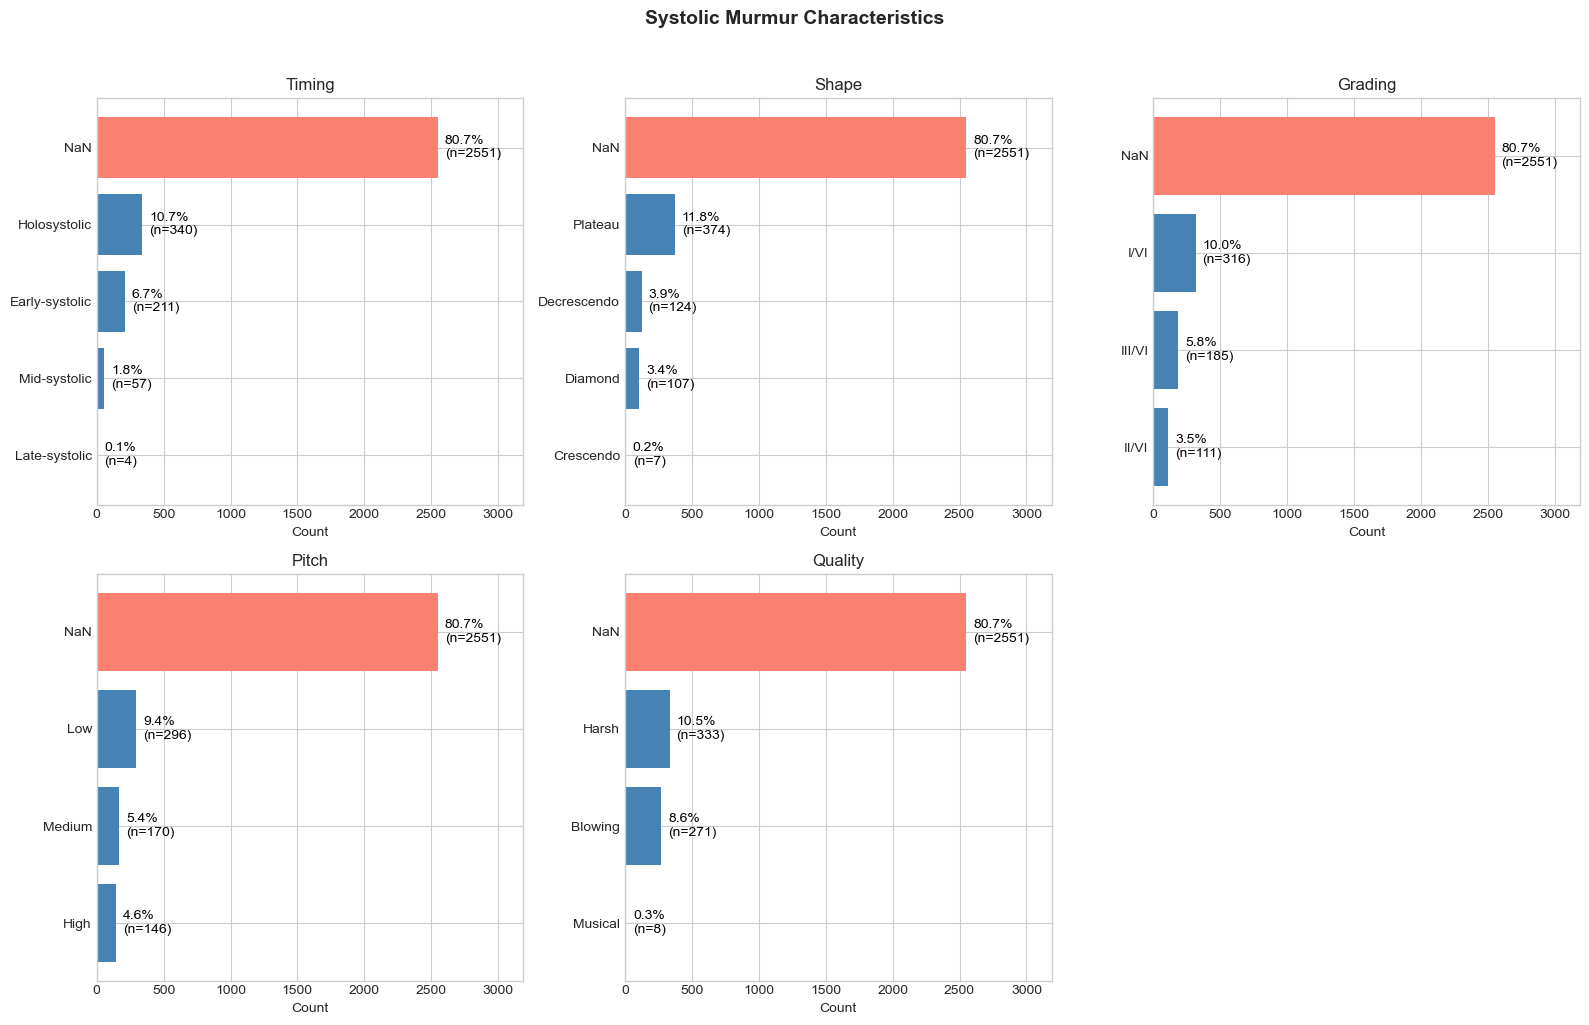

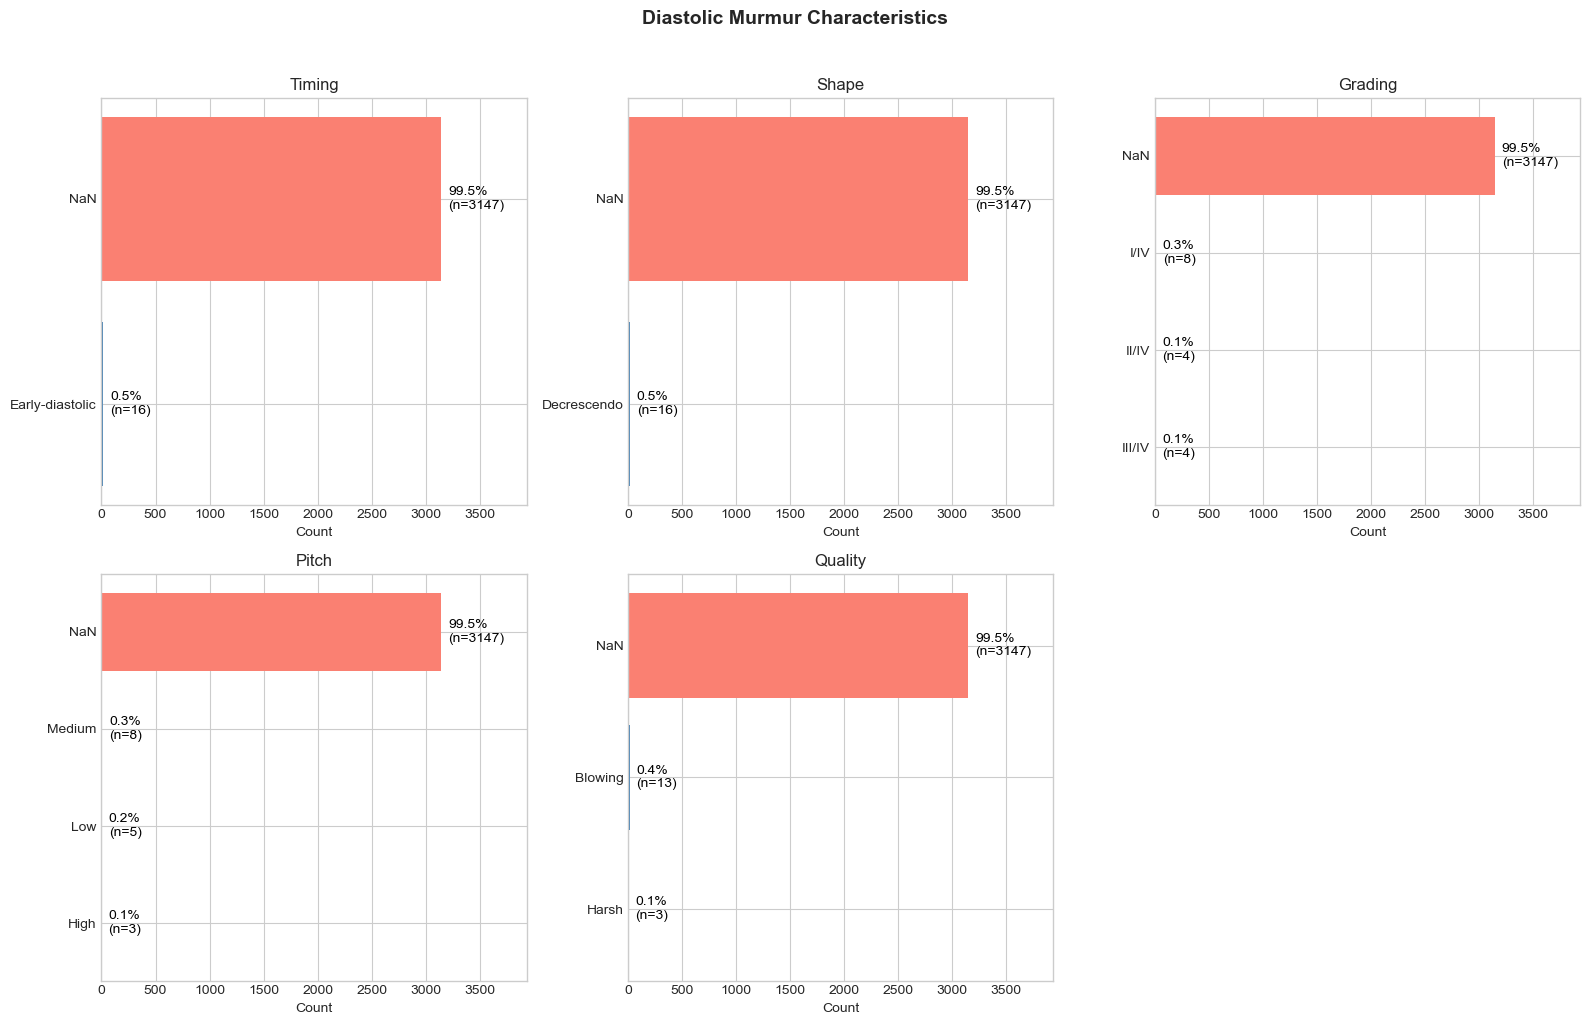

In [10]:
def plot_murmur_group(df, murmur_type='Systolic', figsize=(16, 10)):
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    cols = [f'{murmur_type} murmur timing', f'{murmur_type} murmur shape',
            f'{murmur_type} murmur grading', f'{murmur_type} murmur pitch',
            f'{murmur_type} murmur quality']

    total = len(df)

    for idx, (ax, col) in enumerate(zip(axes, cols)):
        value_counts = df[col].value_counts(dropna=False)
        value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]

        colors = ['salmon' if x == 'NaN' else 'steelblue' for x in value_counts.index]

        bars = ax.barh(value_counts.index, value_counts.values, color=colors)
        ax.set_xlabel('Count')
        ax.set_title(col.replace(f'{murmur_type} murmur ', '').title())
        ax.invert_yaxis()

        max_val = value_counts.max()
        ax.set_xlim(0, max_val * 1.25)
        for bar, count in zip(bars, value_counts.values):
            pct = count / total * 100

            ax.text(bar.get_width() + max_val * 0.02, bar.get_y() + bar.get_height() / 2,
                    f'{pct:.1f}%\n(n={count})', ha='left', va='center', fontsize=10, color='black')

    axes[-1].set_visible(False)

    plt.suptitle(f'{murmur_type} Murmur Characteristics', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_murmur_group(cohort, 'Systolic')
plot_murmur_group(cohort, 'Diastolic')

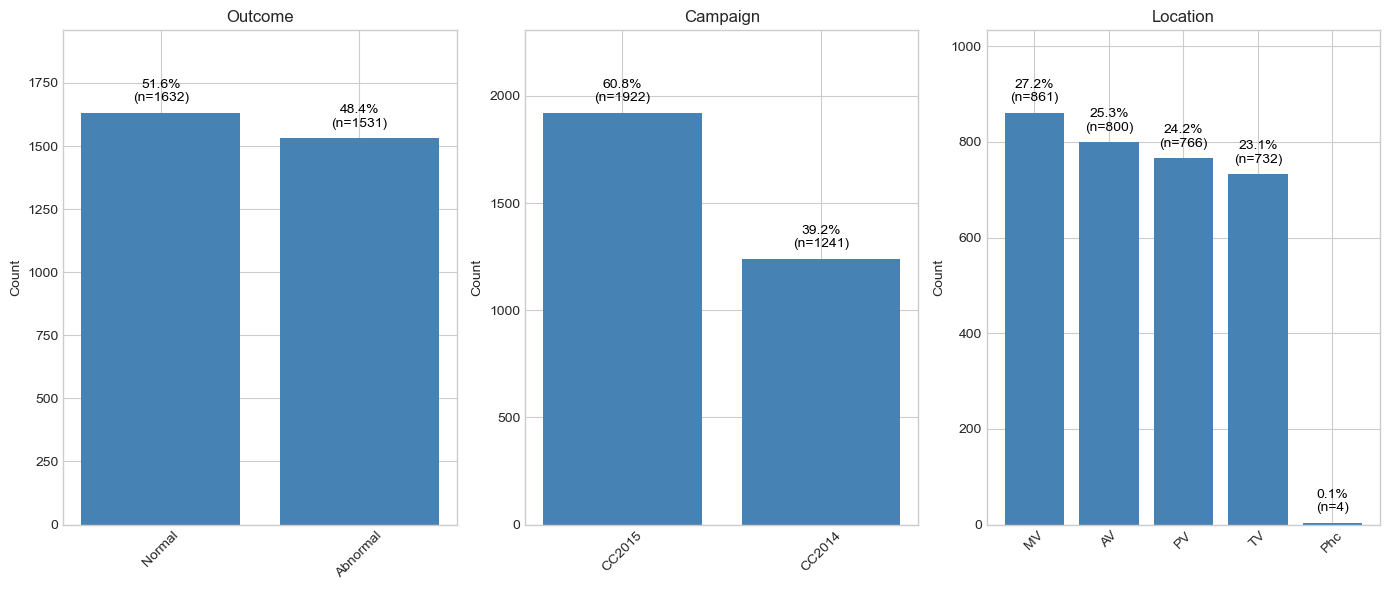

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

cols = ['Outcome', 'Campaign', 'location']
total = len(cohort)

for ax, col in zip(axes, cols):
    value_counts = cohort[col].value_counts(dropna=False)
    value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]

    colors = ['salmon' if x == 'NaN' else 'steelblue' for x in value_counts.index]

    bars = ax.bar(value_counts.index, value_counts.values, color=colors)
    ax.set_ylabel('Count')
    ax.set_title(col.title())
    ax.tick_params(axis='x', rotation=45)

    max_val = value_counts.max()
    ax.set_ylim(0, max_val * 1.2)

    for bar, count in zip(bars, value_counts.values):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.02,
                f'{pct:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

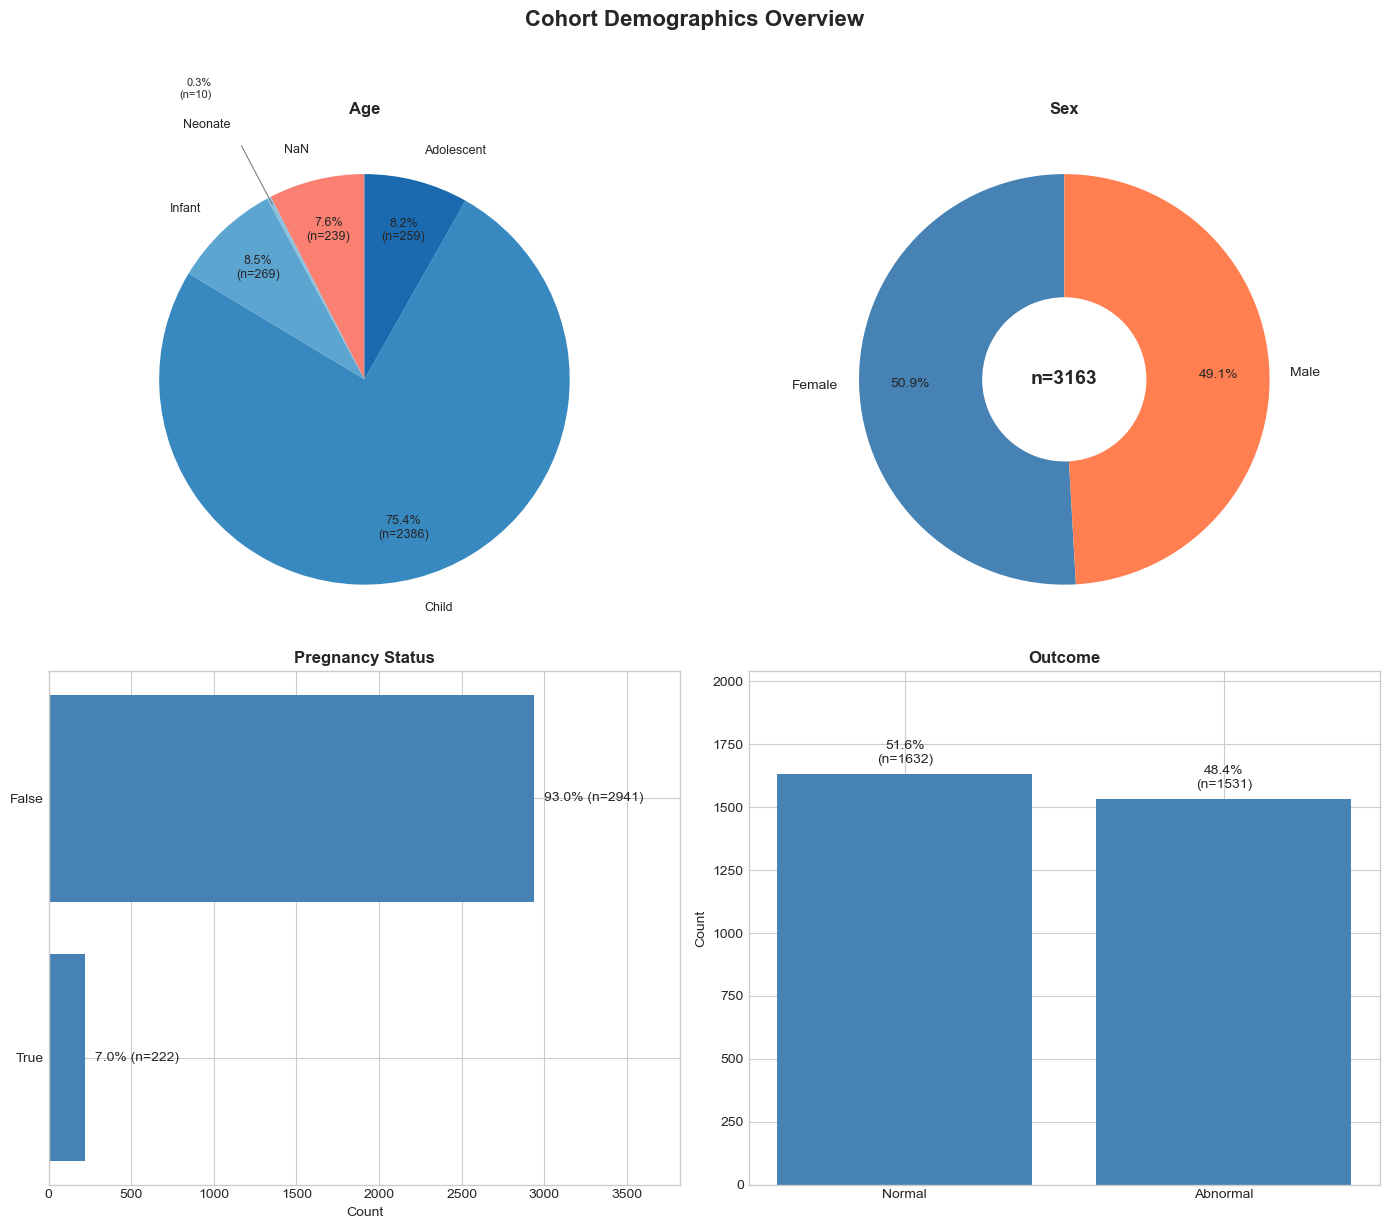

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
total = len(cohort)

# =============================================================================
# 1. AGE - Pie Chart (top left)
# =============================================================================
ax = axes[0, 0]
age_order = ['NaN', 'Neonate', 'Infant', 'Child', 'Adolescent']
value_counts = cohort['Age'].value_counts(dropna=False)
value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]
value_counts = value_counts.reindex(age_order)
colors = ['salmon' if x == 'NaN' else plt.cm.Blues(0.3 + 0.6 * i / len(value_counts))
          for i, x in enumerate(value_counts.index)]

wedges, texts, autotexts = ax.pie(
    value_counts.values,
    labels=value_counts.index,
    autopct=lambda p: f'{p:.1f}%\n(n={int(p*total/100)})',
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.15,
    textprops={'fontsize': 9}
)

threshold = 7.5
for i, (wedge, pct) in enumerate(zip(wedges, value_counts.values / total * 100)):
    if pct < threshold:
        ang = (wedge.theta2 + wedge.theta1) / 2
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))

        horizontalalignment = 'left' if x > 0 else 'right'

        texts[i].set_position((1.4 * x, 1.4 * y))
        texts[i].set_horizontalalignment(horizontalalignment)
        autotexts[i].set_position((1.6 * x, 1.6 * y))
        autotexts[i].set_horizontalalignment(horizontalalignment)
        autotexts[i].set_fontsize(8)

        ax.annotate('',
                    xy=(0.95 * x, 0.95 * y),
                    xytext=(1.3 * x, 1.3 * y),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

ax.set_title('Age', fontsize=12, fontweight='bold')

# =============================================================================
# 2. SEX - Donut Chart (top right)
# =============================================================================
ax = axes[0, 1]
value_counts = cohort['Sex'].value_counts(dropna=False)
value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]
colors = ['salmon' if x == 'NaN' else c for x, c in
          zip(value_counts.index, ['steelblue', 'coral', 'mediumseagreen'])]

wedges, texts, autotexts = ax.pie(
    value_counts.values,
    labels=value_counts.index,
    autopct=lambda p: f'{p:.1f}%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.6),
    pctdistance=0.75
)
ax.text(0, 0, f'n={total}', ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('Sex', fontsize=12, fontweight='bold')

# =============================================================================
# 3. PREGNANCY STATUS - Horizontal Bar (bottom left)
# =============================================================================
ax = axes[1, 0]
value_counts = cohort['Pregnancy status'].value_counts(dropna=False)
value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]
colors = ['salmon' if x == 'NaN' else 'steelblue' for x in value_counts.index]

bars = ax.barh(value_counts.index, value_counts.values, color=colors)
ax.set_xlabel('Count')
ax.set_title('Pregnancy Status', fontsize=12, fontweight='bold')
ax.invert_yaxis()

max_val = value_counts.max()
ax.set_xlim(0, max_val * 1.3)
for bar, count in zip(bars, value_counts.values):
    pct = count / total * 100
    ax.text(bar.get_width() + max_val * 0.02, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}% (n={count})', ha='left', va='center', fontsize=10)

# =============================================================================
# 4. OUTCOME - Vertical Bar (bottom right)
# =============================================================================
ax = axes[1, 1]
value_counts = cohort['Outcome'].value_counts(dropna=False)
value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]
colors = ['salmon' if x == 'NaN' else 'steelblue' for x in value_counts.index]

bars = ax.bar(value_counts.index, value_counts.values, color=colors)
ax.set_ylabel('Count')
ax.set_title('Outcome', fontsize=12, fontweight='bold')

max_val = value_counts.max()
ax.set_ylim(0, max_val * 1.25)
for bar, count in zip(bars, value_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.02,
            f'{pct:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=10)

plt.suptitle('Cohort Demographics Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

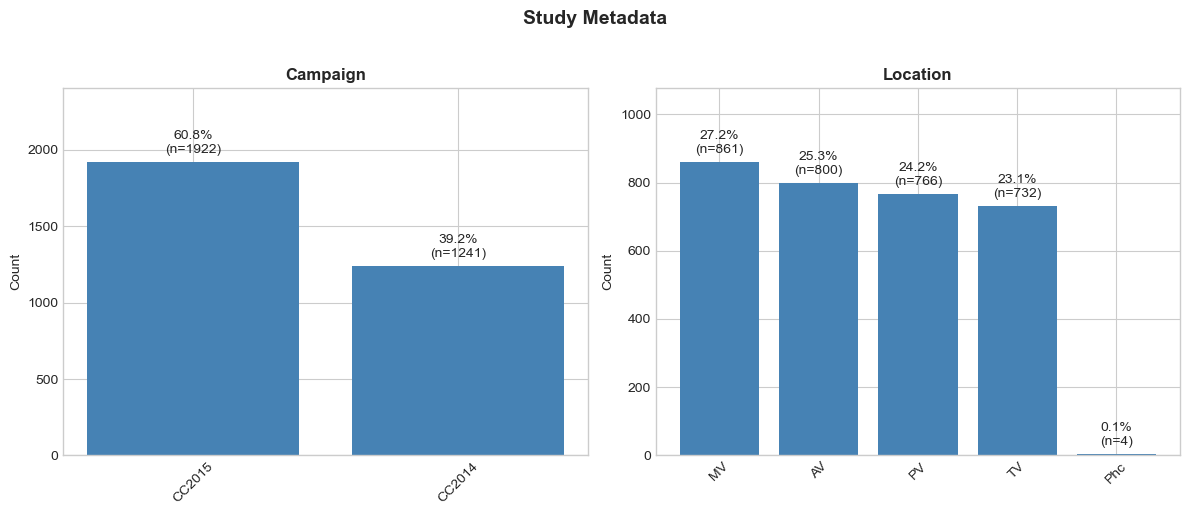

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cols = ['Campaign', 'location']
total = len(cohort)

for ax, col in zip(axes, cols):
    value_counts = cohort[col].value_counts(dropna=False)
    value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]

    colors = ['salmon' if x == 'NaN' else 'steelblue' for x in value_counts.index]

    bars = ax.bar(value_counts.index, value_counts.values, color=colors)
    ax.set_ylabel('Count')
    ax.set_title(col.title(), fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

    max_val = value_counts.max()
    ax.set_ylim(0, max_val * 1.25)

    for bar, count in zip(bars, value_counts.values):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.02,
                f'{pct:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=10)

plt.suptitle('Study Metadata', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

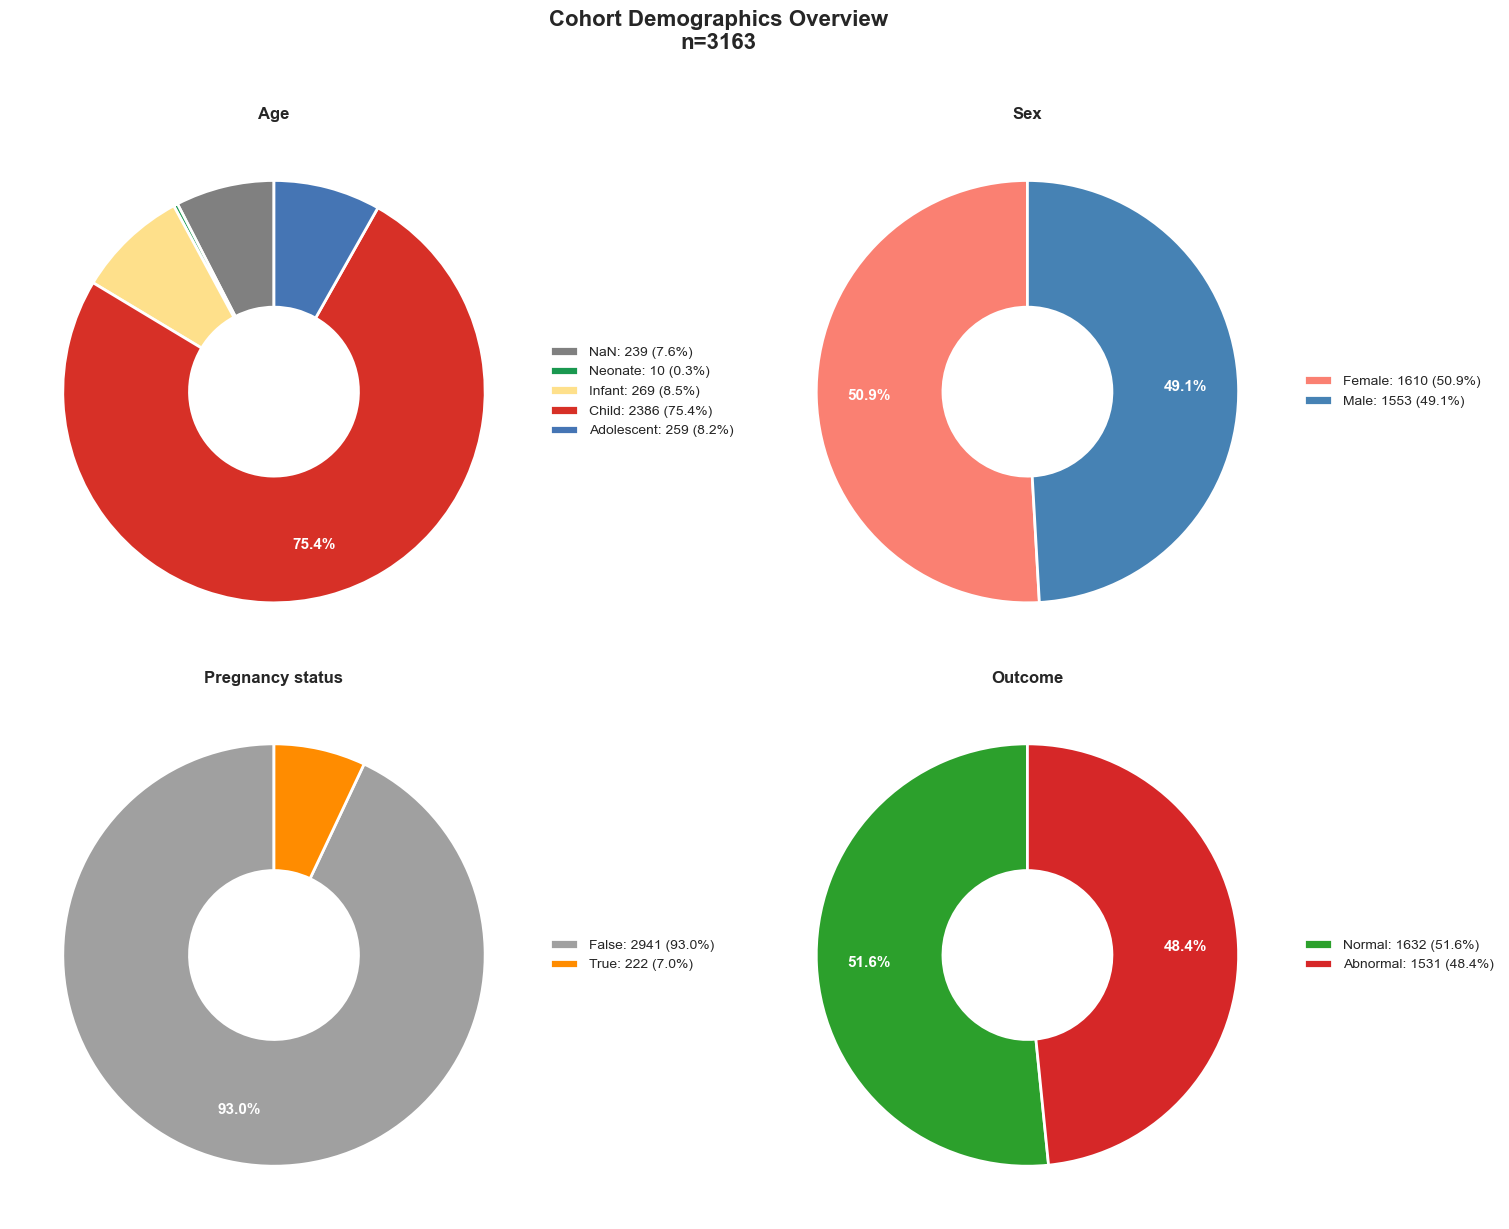

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
total = len(cohort)

# Color palettes
color_palettes = {
    'Age': {
        'NaN': '#808080', 'Neonate': '#1a9850', 'Infant': '#fee08b',
        'Child': '#d73027', 'Adolescent': '#4575b4'
    },
    'Sex': {
        'NaN': '#808080', 'Female': 'salmon', 'Male': 'steelblue'
    },
    'Pregnancy status': {
        'NaN': '#808080', 'False': '#a0a0a0', 'True': '#ff8c00'
    },
    'Outcome': {
        'NaN': '#808080', 'Normal': '#2ca02c', 'Abnormal': '#d62728'
    }
}

plot_configs = [
    ('Age', ['NaN', 'Neonate', 'Infant', 'Child', 'Adolescent']),
    ('Sex', None),
    ('Pregnancy status', None),
    ('Outcome', None)
]

for ax, (col, order) in zip(axes.flatten(), plot_configs):
    value_counts = cohort[col].value_counts(dropna=False)
    value_counts.index = [str(x) if pd.notna(x) else 'NaN' for x in value_counts.index]

    if order:
        value_counts = value_counts.reindex(order)

    palette = color_palettes[col]
    colors = [palette.get(x, 'gray') for x in value_counts.index]

    # Donut without labels
    wedges, texts, autotexts = ax.pie(
        value_counts.values,
        autopct=lambda p: f'{p:.1f}%' if p > 15 else '',
        colors=colors,
        startangle=90,
        wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
        pctdistance=0.75,
        textprops={'fontsize': 11, 'fontweight': 'bold', 'color': 'white'}
    )

    # Center text
    ax.set_title(col, fontsize=12, fontweight='bold')

    # Legend
    legend_labels = [f'{label}: {count} ({count/total*100:.1f}%)'
                     for label, count in value_counts.items()]
    ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

plt.suptitle(f'Cohort Demographics Overview\nn={total}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
patient_level = cohort.drop_duplicates(subset='patient_id')
print(f"Total recordings: {len(cohort)}")
print(f"Unique patients: {len(patient_level)}")

categorical = [
    'Age',
    'Sex',
    'Pregnancy status',
    'Murmur',
    'Outcome',
    'Campaign'
]

continuous = [
    'Height',
    'Weight'
]

order = {
    'Age': ['Neonate', 'Infant', 'Child', 'Adolescent'],
    'Sex': ['Male', 'Female'],
    'Murmur': ['Present', 'Absent', 'Unknown'],
    'Outcome': ['Normal', 'Abnormal'],
    'Pregnancy status': ['True', 'False']
}

table1 = TableOne(
    patient_level,
    columns=categorical + continuous,
    categorical=categorical,
    continuous=continuous,
    order=order,
    missing=True,
    overall=True
)

print(table1.tabulate(tablefmt="fancy_grid"))
table1.to_csv('table_one_patient_level.csv')

table1_by_outcome = TableOne(
    patient_level,
    columns=categorical + continuous,
    categorical=[c for c in categorical if c != 'Outcome'],  # Remove groupby variable
    continuous=continuous,
    groupby='Outcome',
    order=order,
    pval=True,
    missing=True,
    overall=True
)

print("\n" + "=" * 80)
print("TABLE ONE - STRATIFIED BY OUTCOME")
print("=" * 80)
print(table1_by_outcome.tabulate(tablefmt="fancy_grid"))
table1_by_outcome.to_csv('table_one_by_outcome.csv')

table1_by_murmur = TableOne(
    patient_level,
    columns=categorical + continuous,
    categorical=[c for c in categorical if c != 'Murmur'],  # Remove groupby variable
    continuous=continuous,
    groupby='Murmur',
    order=order,
    pval=True,
    missing=True,
    overall=True
)

print("\n" + "=" * 80)
print("TABLE ONE - STRATIFIED BY MURMUR")
print("=" * 80)
print(table1_by_murmur.tabulate(tablefmt="fancy_grid"))
table1_by_murmur.to_csv('table_one_by_murmur.csv')

print("\n" + "=" * 80)
print("LATEX OUTPUT")
print("=" * 80)
print(table1_by_outcome.to_latex())


def patient_summary(df):
    """Quick patient-level summary"""
    print(f"{'=' * 50}")
    print(f"PATIENT CHARACTERISTICS (N={len(df)})")
    print(f"{'=' * 50}\n")

    # Demographics
    print("DEMOGRAPHICS")
    print("-" * 30)
    print(f"Age distribution:")
    print(df['Age'].value_counts(dropna=False).to_string())
    print(f"\nSex:")
    print(df['Sex'].value_counts(dropna=False).to_string())

    print(f"\nHeight (cm): {df['Height'].mean():.1f} ± {df['Height'].std():.1f} (n={df['Height'].notna().sum()})")
    print(f"Weight (kg): {df['Weight'].mean():.1f} ± {df['Weight'].std():.1f} (n={df['Weight'].notna().sum()})")

    # Clinical
    print(f"\nCLINICAL FINDINGS")
    print("-" * 30)
    print(f"Murmur:")
    print(df['Murmur'].value_counts(dropna=False).to_string())
    print(f"\nOutcome:")
    print(df['Outcome'].value_counts(dropna=False).to_string())

    # Study info
    print(f"\nSTUDY INFO")
    print("-" * 30)
    print(f"Campaign:")
    print(df['Campaign'].value_counts(dropna=False).to_string())


patient_summary(patient_level)

Total recordings: 3163
Unique patients: 942
╒═════════════════════════╤════════════╤═══════════╤══════════════╕
│                         │            │ Missing   │ Overall      │
╞═════════════════════════╪════════════╪═══════════╪══════════════╡
│ n                       │            │           │ 942          │
├─────────────────────────┼────────────┼───────────┼──────────────┤
│ Age, n (%)              │ Neonate    │           │ 6 (0.6)      │
├─────────────────────────┼────────────┼───────────┼──────────────┤
│                         │ Infant     │           │ 126 (13.4)   │
├─────────────────────────┼────────────┼───────────┼──────────────┤
│                         │ Child      │           │ 664 (70.5)   │
├─────────────────────────┼────────────┼───────────┼──────────────┤
│                         │ Adolescent │           │ 72 (7.6)     │
├─────────────────────────┼────────────┼───────────┼──────────────┤
│                         │ None       │           │ 74 (7.9)     │
├───

/opt/anaconda3/lib/python3.13/site-packages/tableone/preprocessors.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupbylvls = sorted(data.groupby(groupby).groups.keys())  # type: ignore
/opt/anaconda3/lib/python3.13/site-packages/tableone/tables.py:399: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_cont = pd.pivot_table(cont_data, columns=[groupby], aggfunc=aggfuncs)
/opt/anaconda3/lib/python3.13/site-packages/tableone/tables.py:399: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the curr

InvalidIndexError: slice(None, None, None)